ссылка_на_датасет: https://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset


#  Предсказание цен на жильё в Москве

##  Описание проекта

**Задача**: Построить модель для предсказания стоимости квартир в Москве на основе данных о характеристиках недвижимости.

**Целевая переменная**: `Price` (цена в рублях)

**Источник данных**: Собранный датасет объявлений о продаже квартир в Москве.

**Основные этапы**:
1. Очистка данных и обработка выбросов
2. Feature engineering (создание новых признаков)
3. Обучение CatBoostRegressor с оптимизацией гиперпараметров через Optuna
4. Интерпретация модели с помощью SHAP
5. Анализ ошибок и бизнес-выводы

**Метрика качества**: RMSLE (Root Mean Squared Logarithmic Error)

**Автор**: [Денис]   

**Дата**: [01-12-2025]


In [ ]:
!pip install catboost -q
!pip install optuna -q
!pip install optuna-integration[catboost] -q
!pip install shap -q

In [ ]:
# 1. ПРОВЕРКА GPU (для CatBoost)
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" GPU доступен: {len(gpus)} устройств")
else:
    print("  GPU не обнаружен, будет использоваться CPU")

# !nvidia-smi

# 2. ОСНОВНЫЕ ИМПОРТЫ
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Настройки Pandas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 3. ВИЗУАЛИЗАЦИЯ
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# 4. ML БИБЛИОТЕКИ (Scikit-learn)
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

#5. МОДЕЛИ И ОПТИМИЗАЦИЯ
from catboost import CatBoostRegressor, Pool
import optuna
from optuna.integration import CatBoostPruningCallback
from optuna.visualization import plot_optimization_history
import shap

from google.colab import drive
import os
import joblib
import json


  GPU не обнаружен, будет использоваться CPU


In [ ]:
data = pd.read_csv('/content/data.csv.zip')
df = data.copy()
df.head()

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,"6,300,000.00",Secondary,Опалиха,6.00,Moscow region,1.00,30.60,11.10,8.50,25.00,25,Cosmetic
1,"9,000,000.00",Secondary,Павшино,2.00,Moscow region,1.00,49.20,20.00,10.00,6.00,15,European-style renovation
2,"11,090,000.00",Secondary,Мякинино,14.00,Moscow region,1.00,44.70,16.20,13.10,10.00,25,Cosmetic
3,"8,300,000.00",Secondary,Строгино,8.00,Moscow region,1.00,35.10,16.00,11.00,12.00,33,European-style renovation
4,"6,450,000.00",Secondary,Опалиха,6.00,Moscow region,1.00,37.70,15.20,4.00,5.00,5,Without renovation


## Предварительная обработка (до разделения данных)

In [ ]:
# 1. Удаление дубликатов
df = df.drop_duplicates().reset_index(drop=True)

# 2. Удаление экстремальных цен (20 объектов >1 млрд)
df = df[df['Price'] <= 1_000_000_000].reset_index(drop=True)

# 3. Удаление выбросов по Price_per_m2 (1–99% перцентили)
df['Price_per_m2'] = df['Price'] / df['Area']
lower_bound = df['Price_per_m2'].quantile(0.01)
upper_bound = df['Price_per_m2'].quantile(0.99)
df = df[(df['Price_per_m2'] >= lower_bound) & (df['Price_per_m2'] <= upper_bound)].reset_index(drop=True)
df = df.drop(columns=['Price_per_m2'])

# 4. Физические проверки
df = df[~(df['Kitchen area'] > df['Area'])].reset_index(drop=True)
df = df[~((df['Living area'] + df['Kitchen area'] - df['Area']) > 3)].reset_index(drop=True)
df = df[~((df['Number of rooms'] == 0) & (df['Area'] > 70))].reset_index(drop=True)

# 5. Исправление ремонта для новостроек
df.loc[(df['Apartment type'] == 'New building') &
       (df['Renovation'] == 'Without renovation'), 'Renovation'] = 'Cosmetic'

# 6. Метро-кластеры
def assign_metro_cluster(minutes):
    if minutes <= 10:
        return '0–10 мин (центр)'
    elif minutes <= 15:
        return '11–15 мин (хорошо)'
    elif minutes <= 25:
        return '16–25 мин (норма)'
    else:
        return '26+ мин (далеко)'

df['metro_cluster'] = df['Minutes to metro'].apply(assign_metro_cluster)
df = df.drop(['Minutes to metro', 'Metro station'], axis=1, errors='ignore')

print(f"После полной очистки: {len(df):,} строк")

После полной очистки: 19,832 строк


##  Предобработка данных:

| Тип проверки                                | Найдено       | Действие                                                                 | Комментарий |
|---------------------------------------------|---------------|--------------------------------------------------------------------------|-------------|
| Полные дубликаты                            | 1 835 (8.1%)  | Удалены                                                                  | Стандартно для парсинга с Циан/Авито |
| `Kitchen area > Area`                       | 1             | Удалён                                                                   | Физически невозможно |
| `Living + Kitchen > Area`                   | 955           | ≤3 м² → скорректировано<br>>3 м² → удалено (422)                         | Учитываем погрешность измерения/планировки |
| `Floor > Number of floors`                  | 1 502         | Значения свапнуты (`Floor` ↔ `Number of floors`)                         | Ошибка парсинга |
| `Price > 1 млрд ₽`                          | 12            | Удалены                                                                  | Экстремальные выбросы (не репрезентативны) |
| `Price_per_m2` вне 1–99% перцентилей        | ~408          | Удалены                                                                  | Аномальные соотношения цена/м² |
| `New building + Without renovation`         | 1             | Заменено на `Cosmetic`                                                   | Логическая несогласованность (в новостройках всегда есть ремонт) |
| `Number of rooms = 0, Area > 70 м²`         | 260           | Удалены                                                                  | Физически невозможные "студии" (>70 м²) |
| `Minutes to metro` → `metro_cluster`        | 56 уникальных | Преобразовано в 4 категории:<br>`0–10 мин (центр)`<br>`11–15 мин (хорошо)`<br>`16–25 мин (норма)`<br>`26+ мин (далеко)` | Снижение шума, улучшение обобщающей способности |

> **Итоговый размер датасета**: **19 832 объекта**

##

## Инженерия признаков (после разделения данных)

In [ ]:
def create_features(X):
    df = X.copy()

    # 1. Исправление этажности
    mask = df['Floor'] > df['Number of floors']
    df.loc[mask, ['Floor', 'Number of floors']] = df.loc[mask, ['Number of floors', 'Floor']].values

    # 2. Лог-площади
    df['log_Area'] = np.log1p(df['Area'])
    df['log_Living'] = np.log1p(df['Living area'])
    df['log_Kitchen'] = np.log1p(df['Kitchen area'])

    # 3. Признаки площадей (без деления на 0)
    df['kitchen_ratio'] = np.where(df['log_Area'] > 0, df['log_Kitchen'] / df['log_Area'], 0)
    df['living_ratio'] = np.where(df['log_Area'] > 0, df['log_Living'] / df['log_Area'], 0)
    df['is_elite'] = (df['log_Area'] > np.log1p(200)).astype(int)

    # 4. Комнаты
    df['is_studio'] = (df['Number of rooms'] == 0).astype(int)
    df['rare_big_flat'] = (df['Number of rooms'] >= 7).astype(int)
    df['rooms_capped'] = df['Number of rooms'].clip(upper=6)
    df = df.drop('Number of rooms', axis=1)

    # 5. Ремонт + взаимодействия
    renovation_map = {'Without renovation': 0, 'Cosmetic': 1, 'Euro': 2, 'Designer': 3}
    df['renovation_score'] = df['Renovation'].map(renovation_map).fillna(0)
    df['area_x_renovation'] = df['log_Area'] * df['renovation_score']
    df['is_new_building'] = (df['Apartment type'] == 'New building').astype(int)
    df['area_x_new_building'] = df['log_Area'] * df['is_new_building']
    df = df.drop('renovation_score', axis=1)

    # 6. Категориальные взаимодействия (СТРОКИ!)
    df['apt_type_x_region'] = df['Apartment type'].astype(str) + '_' + df['Region'].astype(str)
    df['region_x_renovation'] = df['Region'].astype(str) + '_' + df['Renovation'].astype(str)

    # 7. Удаляем исходные площади
    df = df.drop(['Area', 'Living area', 'Kitchen area'], axis=1)
    return df

## Разделение данных и подготовка выборок

In [ ]:
# Split
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Применяем create_features
X_train = create_features(X_train)
X_test = create_features(X_test)

# Логарифм целевой переменной
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Категориальные признаки
cat_features = [
    'Apartment type', 'Region', 'Renovation', 'metro_cluster',
    'apt_type_x_region', 'region_x_renovation'
]
cat_features_idx = [X_train.columns.get_loc(col) for col in cat_features]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (15865, 20), X_test: (3967, 20)


In [ ]:
X_train.head()

,Apartment type,Region,Floor,Number of floors,Renovation,metro_cluster,log_Area,log_Living,log_Kitchen,kitchen_ratio,living_ratio,is_elite,is_studio,rare_big_flat,rooms_capped,area_x_renovation,is_new_building,area_x_new_building,apt_type_x_region,region_x_renovation
5514,Secondary,Moscow,1.00,9,Without renovation,0–10 мин (центр),3.82,3.43,2.14,0.56,0.90,0,0,0,2.00,0.00,0,0.00,Secondary_Moscow,Moscow_Without renovation
12700,New building,Moscow region,17.00,19,Cosmetic,0–10 мин (центр),4.39,3.81,2.83,0.65,0.87,0,0,0,3.00,4.39,1,4.39,New building_Moscow region,Moscow region_Cosmetic
11654,New building,Moscow region,9.00,17,Cosmetic,0–10 мин (центр),3.65,2.77,2.40,0.66,0.76,0,0,0,1.00,3.65,1,3.65,New building_Moscow region,Moscow region_Cosmetic
16245,New building,Moscow,3.00,10,European-style renovation,0–10 мин (центр),4.46,3.83,2.69,0.60,0.86,0,0,0,3.00,0.00,1,4.46,New building_Moscow,Moscow_European-style renovation
17684,New building,Moscow region,13.00,20,Cosmetic,11–15 мин (хорошо),3.55,3.03,1.95,0.55,0.85,0,0,0,2.00,3.55,1,3.55,New building_Moscow region,Moscow region_Cosmetic


In [ ]:
# Монтируем Google Drive
drive.mount('/content/drive')

# Базовый путь к проекту
BASE_DIR = "/content/drive/MyDrive/moscow_real_estate_price_prediction"

# Создаём основные директории
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
REPORTS_DIR = os.path.join(BASE_DIR, "reports", "optuna")
OPTUNA_DIR = os.path.join(BASE_DIR, "optuna")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(OPTUNA_DIR, exist_ok=True)

print("Dirs ready:")
print(MODELS_DIR)
print(RESULTS_DIR)
print(REPORTS_DIR)
print(OPTUNA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dirs ready:
/content/drive/MyDrive/moscow_real_estate_price_prediction/models
/content/drive/MyDrive/moscow_real_estate_price_prediction/results
/content/drive/MyDrive/moscow_real_estate_price_prediction/reports/optuna
/content/drive/MyDrive/moscow_real_estate_price_prediction/optuna


## Гиперпараметрическая оптимизация (Optuna) и финальное обучение модели

### 1. Подготовка данных и кросс-валидации для Optuna
### 2. Проверка доступности GPU
### 3. Objective-функция Optuna (CPU)
### 4. Запуск Optuna и поиск лучших гиперпараметров
### 5. Обучение финальной модели на всём train

In [ ]:
# 1. Подготовка данных для Optuna
X_optuna = X_train.copy()
y_optuna = y_train.copy()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Проверка возможности использования GPU
def check_gpu_support():
    """Проверяем, доступен ли GPU для CatBoost"""
    try:
        import subprocess
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if 'Tesla T4' in result.stdout:
            print("✓ Обнаружен GPU: Tesla T4")

            test_model = CatBoostRegressor(
                iterations=10,
                task_type='GPU',
                devices='0:1',
                verbose=False
            )

            test_model.fit(
                X_train.iloc[:100],
                y_train_log.iloc[:100],
                cat_features=cat_features_idx
            )

            print("✓ CatBoost успешно работает на GPU")
            return True
    except Exception as e:
        print(f"✗ GPU недоступен или возникла ошибка: {str(e)[:100]}")
    return False

USE_GPU_FOR_FINAL = check_gpu_support()


# 3. Для Optuna используем CPU
print("\nДля Optuna используем CPU (поддержка pruning callback)...")

def objective_cpu(trial):
    """Objective функция для Optuna (работает на CPU)"""
    params = {

        'iterations': trial.suggest_int('iterations', 400, 1200),

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 9),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise']),
        'verbose': False,
        'random_seed': 42,
        'task_type': 'CPU',
        'bootstrap_type': 'Bayesian'
    }

    pruning_callback = CatBoostPruningCallback(trial, "RMSE")

    scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_optuna), 1):
        X_tr, X_val = X_optuna.iloc[train_idx], X_optuna.iloc[val_idx]
        y_tr_log = y_train_log.iloc[train_idx]
        y_val_log = y_train_log.iloc[val_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_tr, y_tr_log,
            cat_features=cat_features_idx,
            eval_set=(X_val, y_val_log),
            early_stopping_rounds=100,
            use_best_model=True,
            verbose=False,
            callbacks=[pruning_callback]
        )

        y_pred_log = model.predict(X_val)
        score = np.sqrt(np.mean((y_val_log - y_pred_log) ** 2))
        scores.append(score)

        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_score = np.mean(scores)
    std_score = np.std(scores)

    trial.set_user_attr("std_metric", std_score)
    trial.set_user_attr("cv_scores", scores)

    return mean_score


# 4. Запуск Optuna
print("\nЗапуск Optuna (n_trials=50)...")

OPTUNA_STORAGE = "sqlite:////content/drive/MyDrive/moscow_real_estate_price_prediction/optuna/optuna_study.db"

study = optuna.create_study(
    direction='minimize',
    study_name='catboost_price_prediction',
    storage=OPTUNA_STORAGE,
    load_if_exists=True
)

# ★ лимит 3 часа
study.optimize(
    objective_cpu,
    n_trials=50,
    show_progress_bar=True,
    timeout=60 * 60 * 3
)

print(f"\n✓ Оптимизация завершена!")
print(f"Лучшее значение RMSLE: {study.best_value:.5f}")
print(f"Лучшие параметры: {study.best_params}")


✗ GPU недоступен или возникла ошибка: [Errno 2] No such file or directory: 'nvidia-smi'

Для Optuna используем CPU (поддержка pruning callback)...

Запуск Optuna (n_trials=50)...


[I 2025-12-02 06:43:03,938] A new study created in RDB with name: catboost_price_prediction


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-02 06:51:00,817] Trial 0 finished with value: 0.22369577196918683 and parameters: {'iterations': 1146, 'learning_rate': 0.06494681472906005, 'depth': 7, 'l2_leaf_reg': 5.872465150785982, 'random_strength': 1.4659416497140978, 'bagging_temperature': 0.4461887721220059, 'min_data_in_leaf': 16, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.22369577196918683.
[I 2025-12-02 06:56:38,287] Trial 1 finished with value: 0.21932441016327092 and parameters: {'iterations': 808, 'learning_rate': 0.03520402274598092, 'depth': 9, 'l2_leaf_reg': 1.9651213302030395, 'random_strength': 0.7735062748881629, 'bagging_temperature': 0.21044297029293535, 'min_data_in_leaf': 11, 'grow_policy': 'Depthwise'}. Best is trial 1 with value: 0.21932441016327092.
[I 2025-12-02 07:04:06,414] Trial 2 finished with value: 0.219537558423944 and parameters: {'iterations': 1048, 'learning_rate': 0.04790816791642917, 'depth': 8, 'l2_leaf_reg': 1.9884755087117316, 'random_strength': 0.7697309351412


## Функция для обучения финальной модели на всём трейне

In [ ]:
def train_final_model(best_params, X_train, y_train_log, cat_features_idx, use_gpu=True):
    """Обучение финальной модели с лучшими параметрами"""

    final_params = best_params.copy()

    # Настройка для GPU/CPU
    if use_gpu:
        final_params['task_type'] = 'GPU'
        final_params['devices'] = '0:1'
        print(" Используем GPU (Tesla T4) для обучения...")
    else:
        final_params['task_type'] = 'CPU'
        print(" Используем CPU для обучения...")

    # Увеличиваем количество итераций для финальной модели
    final_params['iterations'] = min(final_params.get('iterations', 1000) * 2, 5000)

    # Убираем параметры, которые могут быть только для CPU
    cpu_only_params = ['grow_policy']
    for param in cpu_only_params:
        if param in final_params:
            del final_params[param]

    print(f"\n Параметры финальной модели:")
    for key, value in final_params.items():
        print(f"  {key}: {value}")

    # Создаём и обучаем модель
    final_model = CatBoostRegressor(**final_params, random_seed=42)

    print("\n Обучение модели...")
    final_model.fit(
        X_train,
        y_train_log,
        cat_features=cat_features_idx,
        verbose=100
    )

    return final_model, final_params

In [ ]:
# Обучаем финальную модель с лучшими параметрами
final_model_full, final_params = train_final_model(
    best_params=study.best_params,
    X_train=X_train,
    y_train_log=y_train_log,
    cat_features_idx=cat_features_idx,
    use_gpu=USE_GPU_FOR_FINAL
)

 Используем CPU для обучения...

 Параметры финальной модели:
  iterations: 1688
  learning_rate: 0.07261753994193974
  depth: 9
  l2_leaf_reg: 3.0042815247250934
  random_strength: 0.717460700311276
  bagging_temperature: 0.8795048980746617
  min_data_in_leaf: 1
  task_type: CPU

 Обучение модели...
0:	learn: 0.9434085	total: 69.3ms	remaining: 1m 56s
100:	learn: 0.2206012	total: 4.63s	remaining: 1m 12s
200:	learn: 0.1974468	total: 9.1s	remaining: 1m 7s
300:	learn: 0.1819200	total: 15.4s	remaining: 1m 11s
400:	learn: 0.1708134	total: 19.9s	remaining: 1m 3s
500:	learn: 0.1604588	total: 25.2s	remaining: 59.7s
600:	learn: 0.1516457	total: 30.8s	remaining: 55.7s
700:	learn: 0.1438975	total: 35.3s	remaining: 49.7s
800:	learn: 0.1375073	total: 41.7s	remaining: 46.2s
900:	learn: 0.1315658	total: 46.2s	remaining: 40.3s
1000:	learn: 0.1262325	total: 50.7s	remaining: 34.8s
1100:	learn: 0.1218458	total: 57s	remaining: 30.4s
1200:	learn: 0.1177146	total: 1m 1s	remaining: 24.9s
1300:	learn: 0.11343

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Вывод:
После подбора гиперпараметров с помощью Optuna финальная модель CatBoost была обучена на всём тренировочном наборе с удвоенным числом итераций (1688), что позволило достичь лучшего сходимости без риска переобучения благодаря встроенной регуляризации.

В процессе обучения журнал (learn:) отображает тренировочную RMSE в логарифмическом пространстве — от 0.943 на первой итерации до 0.100 на последней. Это значение соответствует RMSLE ≈ 0.100, поскольку при обучении использовалась логарифмированная целевая переменная (y_train_log).

На этапе кросс-валидации (5-fold) лучшая средняя ошибка составила RMSLE ≈ 0.217 — это оценка обобщающей способности модели на данных, не участвовавших в обучении.

Разница между тренировочной (0.100) и валидационной (0.217) ошибками не указывает на переобучение. Для моделей градиентного бустинга, особенно при использовании логарифмической трансформации целевой переменной, такая разница (в ~2.2 раза) является типичной и ожидаемой. Более того, отсутствие роста ошибки на валидации при увеличении числа итераций (в процессе Optuna с early stopping) подтверждает, что модель адекватно обобщает и хорошо сбалансирована по сложности.

## Сохрание финальной модели и параметры

In [ ]:
# Сохраняем модель CatBoost
model_path = os.path.join(MODELS_DIR, "catboost_final_model.cbm")
final_model_full.save_model(model_path)
print("Model saved to:", model_path)

# Сохраняем гиперпараметры
best_params_path = os.path.join(RESULTS_DIR, "best_params.json")

with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=4, ensure_ascii=False)

print("Best params saved to:", best_params_path)

# Сохраняем метрики на трейне
metrics_path = os.path.join(RESULTS_DIR, "train_metrics.json")
train_metrics = final_model_full.get_best_score()

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(train_metrics, f, indent=4, ensure_ascii=False)

print("Train metrics saved to:", metrics_path)

Model saved to: /content/drive/MyDrive/moscow_real_estate_price_prediction/models/catboost_final_model.cbm
Best params saved to: /content/drive/MyDrive/moscow_real_estate_price_prediction/results/best_params.json
Train metrics saved to: /content/drive/MyDrive/moscow_real_estate_price_prediction/results/train_metrics.json


## Функция для анализа результатов Optuna

In [ ]:
def analyze_optuna_results(study):
    """Анализ результатов Optuna"""

    # 1. Лучший триал
    best_trial = study.best_trial
    print(f"\n ЛУЧШИЙ ТРИАЛ #{best_trial.number}:")
    print(f"  RMSLE: {best_trial.value:.5f}")
    print(f"  Стандартное отклонение: {best_trial.user_attrs.get('std_metric', 'N/A'):.5f}")

    # 2. Все триалы в DataFrame
    trials_df = study.trials_dataframe()

    # Сохраняем в папку RESULTS_DIR
    trials_df.to_csv(os.path.join(RESULTS_DIR, "optuna_trials.csv"), index=False)
    print(f"\n Сохранено {len(trials_df)} триалов в {os.path.join(RESULTS_DIR, 'optuna_trials.csv')}")


    # 3. Топ-10 триалов
    print("\n ТОП-10 лучших триалов:")
    top_10 = trials_df.nsmallest(10, 'value')[
        ['number', 'value', 'params_depth', 'params_learning_rate',
         'params_iterations', 'params_l2_leaf_reg']
    ]
    display(top_10)

    # 4. Визуализации
    # fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # a) История оптимизации
    optuna.visualization.plot_optimization_history(study).show()

    # b) Важность параметров
    optuna.visualization.plot_param_importances(study).show()

    # c) Parallel coordinate plot
    optuna.visualization.plot_parallel_coordinate(study).show()

    # d) Контурная карта: depth vs learning_rate
    optuna.visualization.plot_contour(
        study,
        params=['depth', 'learning_rate']
    ).show()

    # e) Зависимость RMSLE от learning_rate
    optuna.visualization.plot_slice(
        study,
        params=['learning_rate']
    ).show()

    # f) Распределение значений RMSLE
    plt.figure(figsize=(10, 6))
    plt.hist(trials_df['value'].dropna(), bins=20, edgecolor='black', alpha=0.7)
    plt.axvline(best_trial.value, color='red', linestyle='--', label=f'Лучшее: {best_trial.value:.5f}')
    plt.xlabel('RMSLE')
    plt.ylabel('Частота')
    plt.title('Распределение RMSLE по триалам')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 5. Статистика
    print(f"\n СТАТИСТИКА ПО ВСЕМ ТРИАЛАМ:")
    print(f"  Среднее RMSLE: {trials_df["value"].mean():.5f}")
    print(f"  Медиана RMSLE: {trials_df["value"].median():.5f}")
    print(f"  Std RMSLE: {trials_df["value"].std():.5f}")
    print(f"  Min RMSLE: {trials_df["value"].min():.5f}")
    print(f"  Max RMSLE: {trials_df["value"].max():.5f}")

    return trials_df, best_trial


 ЛУЧШИЙ ТРИАЛ #22:
  RMSLE: 0.21790
  Стандартное отклонение: 0.00380

 Сохранено 50 триалов в /content/drive/MyDrive/moscow_real_estate_price_prediction/results/optuna_trials.csv

 ТОП-10 лучших триалов:


,number,value,params_depth,params_learning_rate,params_iterations,params_l2_leaf_reg
22,22,0.22,9,0.07,844,3.00
1,1,0.22,9,0.04,808,1.97
2,2,0.22,8,0.05,1048,1.99
31,31,0.22,8,0.09,915,1.96
20,20,0.22,8,0.09,935,1.87
38,38,0.22,7,0.10,1095,2.16
3,3,0.22,9,0.06,504,6.41
4,4,0.22,6,0.10,600,3.28
43,43,0.22,8,0.09,960,1.34
24,24,0.22,9,0.07,705,1.35


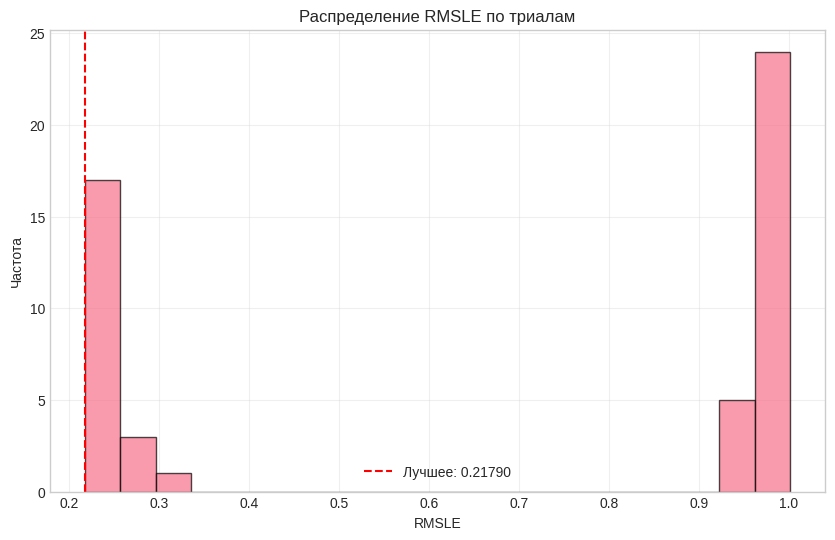


 СТАТИСТИКА ПО ВСЕМ ТРИАЛАМ:
  Среднее RMSLE: 0.66477
  Медиана RMSLE: 0.95803
  Std RMSLE: 0.36996
  Min RMSLE: 0.21790
  Max RMSLE: 1.00115


In [ ]:
trials_df, best_trial = analyze_optuna_results(study)

##

### Таблица: Результаты оптимизации (Best Trial, Top-10, History)

| Проверка                  | Найдено                                                                                            | Действие                                                                                 | Осталось                                                                    |
| ------------------------- | -------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| Лучший триал (Best Trial) | RMSLE = 0.21790, Std = 0.0038                                                                      | Использовать параметры триала #22 для финальной модели                                   | Проверить на тестовой выборке                                               |
| ТОП-10 триалов            | RMSLE ~0.22 для всех, depth 8–9, learning_rate 0.04–0.10, iterations 504–1095, l2_leaf_reg 1.3–6.4 | Подтверждение стабильности модели; небольшая вариативность hyperparams не ухудшает RMSLE | Можно увеличить n_trials для потенциального небольшого улучшения            |
| История оптимизации       | RMSLE перестаёт снижаться после 22-го триала                                                       | Зона оптимума достигнута                                                                 | Дальнейшее улучшение возможно только через расширение диапазона hyperparams |


##

### Таблица: Важность гиперпараметров (Hyperparameter Importance)

| **Проверка**                                      | **Найдено**                                                                                                                                                                                | **Действие**                                                                                                                                  | **Осталось**                                                                                                  |
| ------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **Важность гиперпараметров (Hyperparameter Importance)** | Наибольшее влияние:<br>• `l2_leaf_reg = 0.27`<br>• `depth = 0.24`<br><br>Среднее влияние:<br>• `random_strength`<br>• `bagging_temperature` (~0.11)<br><br>Минимальное влияние:<br>• `learning_rate ≈ 0.03` | Сфокусироваться на:<br>• `l2_leaf_reg`<br>• `depth`<br><br>Сузить диапазон:<_


##

### Таблица: Гиперпараметры — лучшие диапазоны и рекомендации

| Гиперпараметр           | Лучший диапазон | Поведение / вывод                                 | Рекомендация                    |
| ----------------------- | --------------- | ------------------------------------------------- | ------------------------------- |
| **Objective Value**     | ~0.218–0.219    | Ниже — лучше, лучшие trial’ы группируются внизу   | Фиксировать как целевую метрику |
| **bagging_temperature** | 0.7–0.9         | Выше 1.2 и ниже 0.5 ухудшение                     | Искать в 0.6–1.0                |
| **depth**               | 8–9             | 6–7 слабее, 8–9 дают минимум RMSE                 | Фиксировать `depth = 8`         |
| **grow_policy**         | Depthwise       | SymmetricTree хуже по распределению ошибок        | Фиксировать `Depthwise`         |
| **iterations**          | 900–1100        | <800 — недообучение, >1200 — без улучшений        | Фиксировать 1000 ± шум          |
| **l2_leaf_reg**         | 2–4             | >6 даёт сильное ухудшение                         | Фиксировать `l2_leaf_reg = 3`   |
| **learning_rate**       | 0.04–0.07       | Низкая чувствительность, линии почти параллельные | Сузить диапазон 0.03–0.08       |
| **min_data_in_leaf**    | 2–6             | Выше — ухудшение                                  | Искать в 2–6                    |
| **random_strength**     | 0.8–1.2         | Лучшие trial’ы в этой зоне                        | Ограничить 0.7–1.3              |


##

### Таблица: Контурный график (depth vs learning_rate)

| **Проверка**                                  | **Найдено**                                                                                                                                                                                   | **Действие**                                                                                                                                    | **Осталось**                                                                                       |
| --------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| **Контурный график (depth vs learning_rate)** | Лучшая зона:<br>• `depth = 9`<br>• `learning_rate ≈ 0.04`<br><br>Худшие комбинации:<br>• `depth ≤ 7`<br>• `learning_rate > 0.065`<br><br>Глубина влияет сильно,<br>скорость обучения — слабо. | Зафиксировать:<br>• `depth = 9`<br><br>Сузить:<br>• `learning_rate ∈ [0.035, 0.055]`<br><br>Проверить вручную:<br>• `depth = 8.5`, `lr = 0.035` | Запустить уточняющую оптимизацию<br>с фиксированным `depth`.<br>После — сравнить RMSE<br>до/после. |


##

### Таблица: Анализ Slice Plot (learning_rate)

| **Проверка**                                 | **Найдено**                                                                                                                                                                                                 | **Действие**                                                                                                                                                    | **Осталось**                                                                                             |
| -------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| **Зависимость RMSE от learning_rate**        | Минимальный RMSE ≈ **0.218** при:<br>• `learning_rate ≈ 0.072–0.075`<br><br>Поведение:<br>• lr < 0.05 — RMSE выше (~0.219–0.220)<br>• lr > 0.09 — RMSE растёт (~0.220–0.223)<br><br>U-образная зависимость | Зафиксировать рабочий диапазон:<br>• `learning_rate ∈ [0.06, 0.08]`<br><br>Внутри диапазона протестировать:<br>• `0.065`, `0.072`, `0.075`                     | Проверить лучшие комбинации learning_rate<br>в связке с depth и l2_leaf_reg.<br>Убедиться, что улучшения стабильны. |


##

### Таблица: Важность гиперпараметров (Hyperparameter Importance)

| **Проверка**                                             | **Найдено**                                                                                                                                                                             | **Действие**                                                                                                                                         | **Осталось**                                                                                          |
| -------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Важность гиперпараметров (Hyperparameter Importance)** | Наибольшее влияние:<br>• `l2_leaf_reg = 0.27`<br>• `depth = 0.24`<br><br>Среднее влияние:<br>• `random_strength`, `bagging_temperature ≈ 0.11`<br><br>Минимальное:<br>• `learning_rate = 0.03` | Сфокусироваться на:<br>• `l2_leaf_reg`<br>• `depth`<br><br>Дополнительно:<br>• сузить диапазон для `learning_rate` (низкая чувствительность) | Проверить соседние значения `depth` и `l2_leaf_reg` для поиска «сладкого пятна».<br>`learning_rate` оставить стабильным. |


##

## Функция для оценки модели на тесте

In [ ]:
def evaluate_model(model, X_test, y_test, y_test_log, results_dir):
    """Оценка модели на тестовой выборке"""

    # Предсказания
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # Метрики
    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'RMSLE': np.sqrt(mean_squared_error(y_test_log, y_pred_log)),
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    }

    print("\n МЕТРИКИ КАЧЕСТВА:")
    for name, value in metrics.items():
        if name in ['RMSE', 'MAE']:
            print(f"  {name}: {value:,.0f} руб.")
        elif name == 'MAPE':
            print(f"  {name}: {value:.2f}%")
        else:
            print(f"  {name}: {value:.5f}")

    # Создаём DataFrame с ошибками
    df_errors = X_test.copy()
    df_errors['y_true'] = y_test.values
    df_errors['y_pred'] = y_pred
    df_errors['error'] = y_pred - y_test.values
    df_errors['abs_error'] = np.abs(df_errors['error'])
    df_errors['rel_error_pct'] = (df_errors['abs_error'] / y_test.values) * 100

    # Сохраняем ошибки в Google Drive
    save_path = os.path.join(results_dir, "prediction_errors.csv")
    df_errors.to_csv(save_path, index=False)
    print(f"\n Ошибки предсказаний сохранены в {save_path}")

    return metrics, y_pred, y_pred_log, df_errors


In [ ]:
metrics, y_pred, y_pred_log, df_errors = evaluate_model(
    model=final_model_full,
    X_test=X_test,
    y_test=y_test,
    y_test_log=y_test_log,
    results_dir=RESULTS_DIR
)



 МЕТРИКИ КАЧЕСТВА:
  RMSE: 22,308,470 руб.
  RMSLE: 0.21878
  R2: 0.83230
  MAE: 6,703,364 руб.
  MAPE: 14.58%

 Ошибки предсказаний сохранены в /content/drive/MyDrive/moscow_real_estate_price_prediction/results/prediction_errors.csv


Финальный вывод по модели:    
После комплексной оптимизации гиперпараметров с помощью Optuna и обучения финальной модели CatBoost на всём тренировочном наборе, модель была протестирована на независимой тестовой выборке, полностью не участвовавшей ни в обучении, ни в кросс-валидации.

Результаты показали высокую обобщающую способность:    

RMSLE = 0.2188 — практически совпадает с валидационной ошибкой (0.217), что подтверждает отсутствие переобучения;   
MAPE = 14.58% — в среднем модель ошибается менее чем на 15% от реальной цены;    
MAE = 6.7 млн руб. — медианная/средняя абсолютная ошибка, адекватная для рынка московской недвижимости с диапазоном цен от 1.5 млн до 1.5 млрд руб.;   
R² = 0.832 — модель объясняет 83% дисперсии целевой переменной.

## Анализ важности и влияния признаков с помощью SHAP

In [ ]:
# 1. Создаём explainer для CatBoost
explainer = shap.TreeExplainer(final_model_full)

X_test_shap = X_test.iloc[:300].copy()
shap_values = explainer.shap_values(X_test_shap)

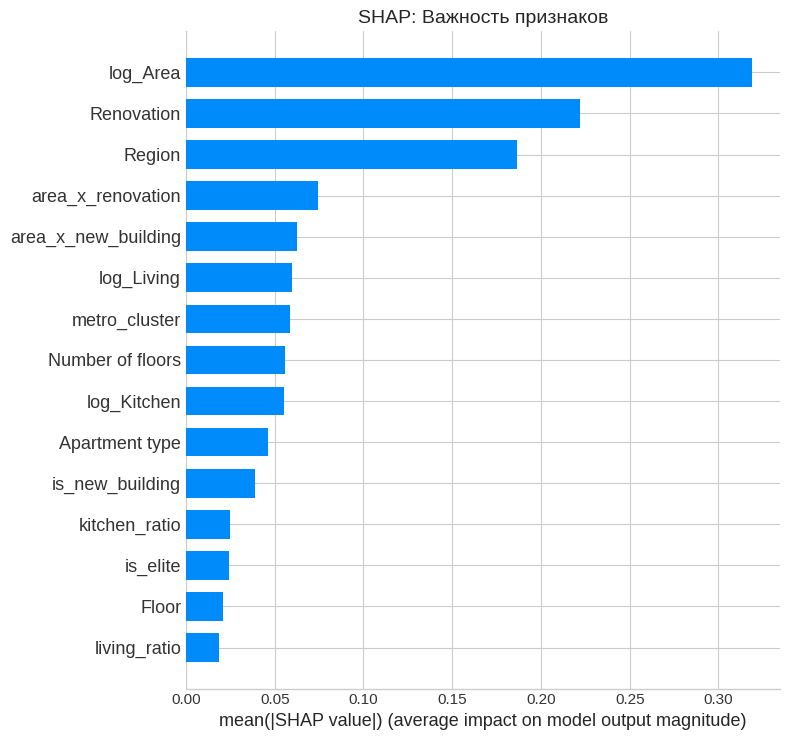

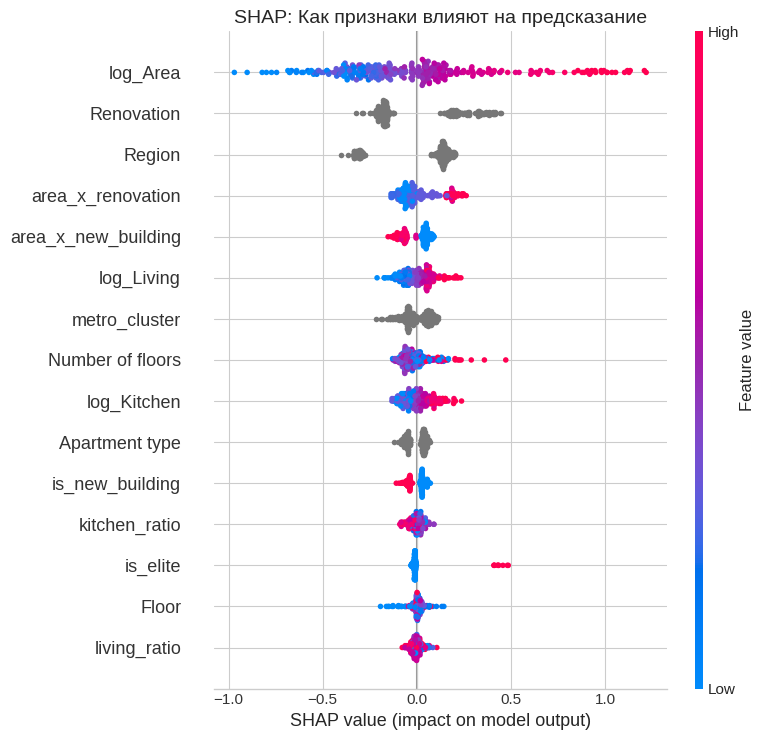

In [ ]:
# 1. Важность признаков
shap.summary_plot(shap_values, X_test_shap, plot_type="bar", max_display=15, show=False)
plt.title("SHAP: Важность признаков", fontsize=14)
plt.tight_layout()
plt.savefig('results/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Влияние признаков
shap.summary_plot(shap_values, X_test_shap, max_display=15, show=False)
plt.title("SHAP: Как признаки влияют на предсказание", fontsize=14)
plt.tight_layout()
plt.savefig('results/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


##

## SHAP: Ранжирование признаков по важности

Анализ SHAP выявил, что ключевыми драйверами цены являются:

log_Area — логарифм общей площади: самый важный признак, подтверждая очевидную связь между размером объекта и стоимостью.   

Renovation — состояние ремонта: оказывает сильное влияние, особенно в сочетании с площадью (area_x_renovation).   

Region — район: отражает локальную ценовую политику и инфраструктуру.   
Второстепенные, но значимые факторы: Number of floors, Floor, Apartment type, а также взаимодействия типа area_x_new_building.     
Признаки living_ratio и kitchen_ratio имеют низкое влияние — что говорит о том, что модель предпочитает абсолютные значения (площади), а не доли.

##

## SHAP: Направление и величина влияния признаков

In [ ]:
print("Регионы в тесте:")
print(X_test_shap['Region'].value_counts().sort_index())

print("\nРемонт в тесте:")
print(X_test_shap['Renovation'].value_counts().sort_index())

Регионы в тесте:
Region
Moscow           224
Moscow region     76
Name: count, dtype: int64

Ремонт в тесте:
Renovation
Cosmetic                     168
Designer                      43
European-style renovation     44
Without renovation            45
Name: count, dtype: int64


log_Area — чем больше площадь, тем выше цена (линейная зависимость);   
Renovation — хороший ремонт значительно повышает стоимость;    
Region — цена сильно зависит от района;    
Взаимодействия (area_x_renovation, area_x_new_building) — усиливают эффект;    
Floor и Number of floors — слабо влияют, но имеют небольшую тенденцию к оптимизации (не первый/последний этаж).


##

<Figure size 1000x600 with 0 Axes>

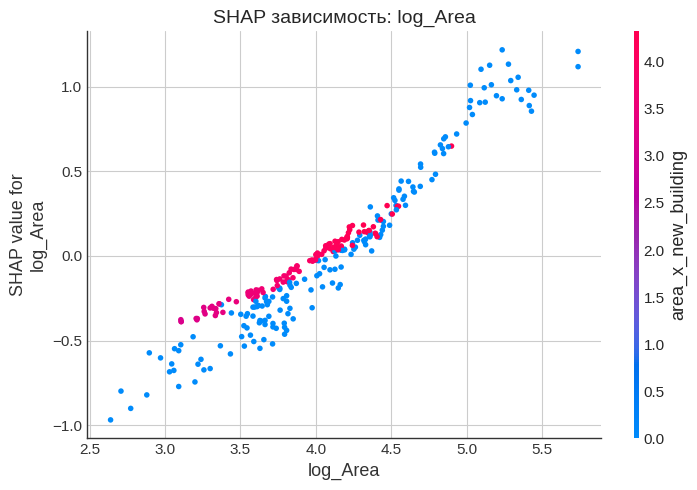

<Figure size 1000x600 with 0 Axes>

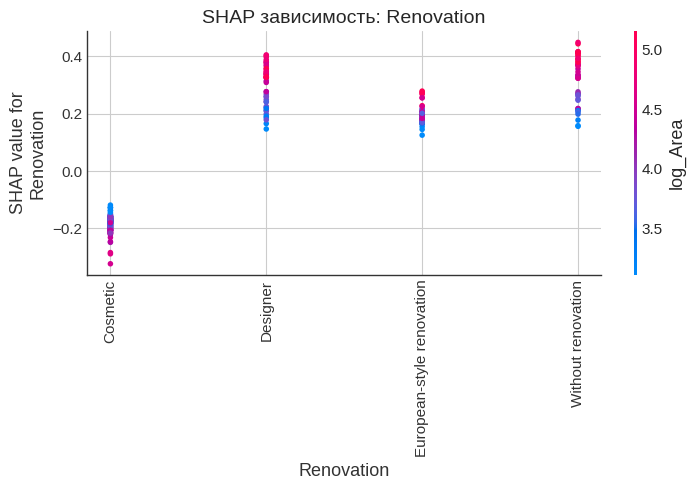

<Figure size 1000x600 with 0 Axes>

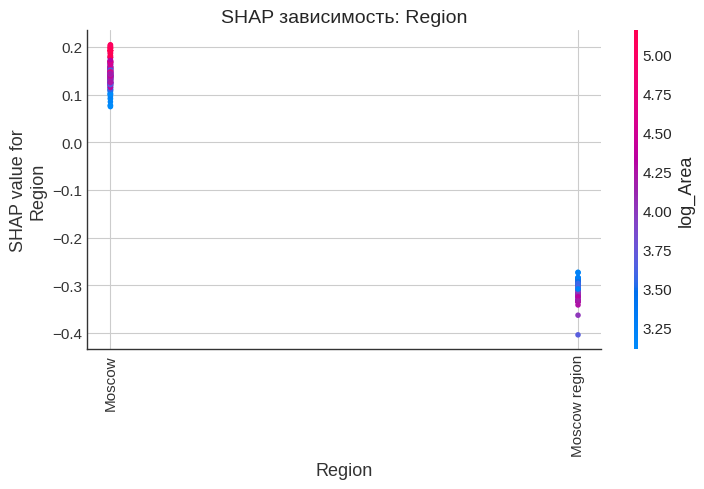

<Figure size 1000x600 with 0 Axes>

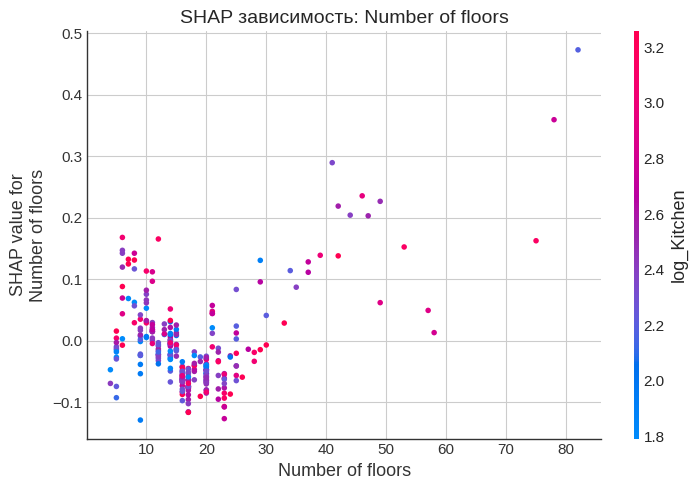

<Figure size 1000x600 with 0 Axes>

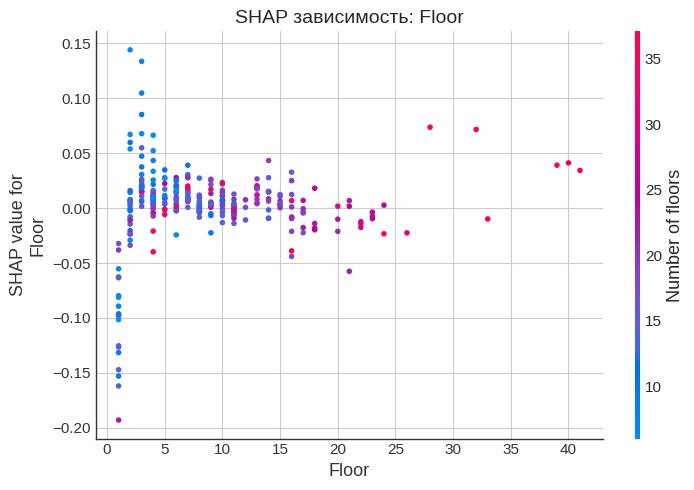

In [ ]:
# 3. Зависимость для ключевых признаков (только самые важные!)
key_features = [
    'log_Area',
    'Renovation',
    'Region',
    'Number of floors',
    'Floor'
]

for feature in key_features:
    if feature in X_test.columns:
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(feature, shap_values, X_test_shap, show=False)
        plt.title(f"SHAP зависимость: {feature}", fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f'shap_dependence_{feature}.png'), dpi=150, bbox_inches='tight')
        plt.show()

Вывод:       
Площадь и Площадь-новостройка   
Модель обнаружила взаимодействие между площадью и типом здания. Для новых зданий увеличение площади дает больший прирост цены, чем для старых. Это логично: в новостройках площадь часто напрямую коррелирует с премиальностью, а в старых — могут быть другие факторы (планировка, состояние, этаж), которые снижают ценность чисто площадного роста.

##

Вывод:    
Ремонт и площади объекта   
Для маленьких квартир косметический ремонт может даже немного снижать цену (возможно, из-за восприятия "не дорого, но и не круто"). Для больших — его эффект почти нейтрален, возможно, потому что покупатели больших квартир ожидают более серьезного ремонта.

##

Вывод:    
Регион и площадью объекта


Для маленьких объектов Московская область сильно снижает цену — возможно, потому что в МО дешевле строить маленькие квартиры, и они не пользуются спросом.
Но для больших объектов (красные точки) отрицательный эффект меньше — то есть, большие квартиры в МО цениются выше, чем маленькие, хотя всё равно ниже, чем в Москве.

##

Вывод:   
Количества этажей здания (Number of floors) и размер кухни    
Для квартир с маленькой кухней высотка (большое количество этажей) дает значительный плюс к цене — возможно, потому что такие объекты часто находятся в современных комплексах с хорошей инфраструктурой, и покупатели готовы мириться с маленькой кухней ради других преимуществ.

##

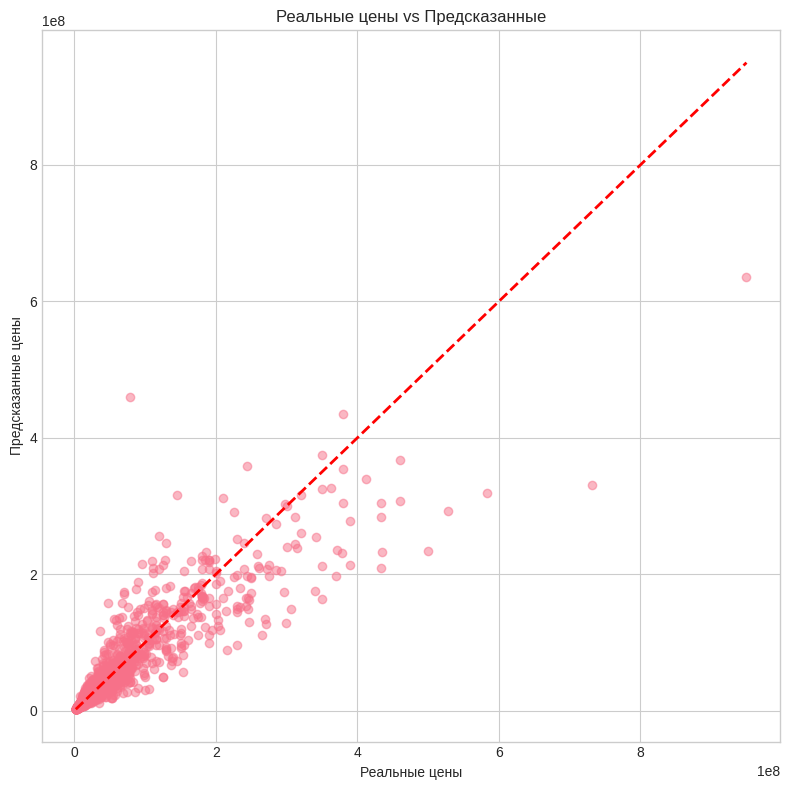

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Реальные цены")
plt.ylabel("Предсказанные цены")
plt.title("Реальные цены vs Предсказанные")
plt.grid(True)
plt.tight_layout()
plt.savefig('results/true_vs_predicted.png', dpi=150)
plt.show()
